In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_40644\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_40644\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[26  2 24  8  3  6 25 22 14  7 10 23 17 18 19 15  0  5 16 13  1 20]
>>> best_lam returning: 7.017038286703837
frac null:  0.7658791186537532
frac potent:  0.23412088134624745


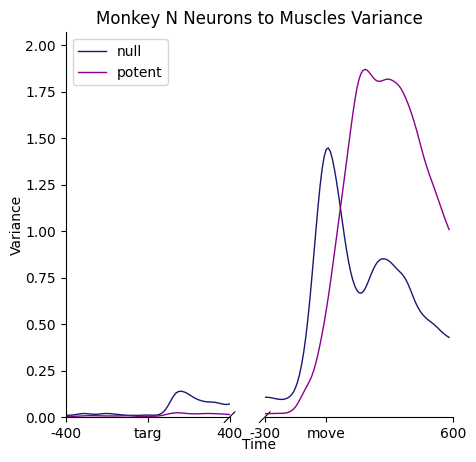

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[25 16 14 21 15  8 26 11 22 24 23  2 18  3 20  5  1 13  4 10 19  9]
>>> best_lam returning: 4.124626382901356
frac null:  0.5964223090291115
frac potent:  0.40357769097088775


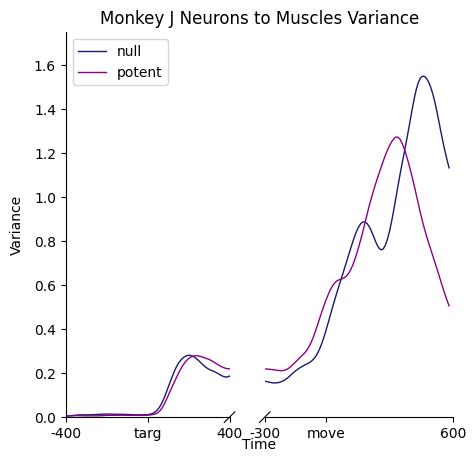

In [4]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[ 3  6  2  4 22  8  1 11 21 17 26  9 23 24  7 16 12 18  5 13 15 19]
>>> best_lam returning: 7.017038286703837
frac null:  0.5672446442099518
frac potent:  0.43275535579005037


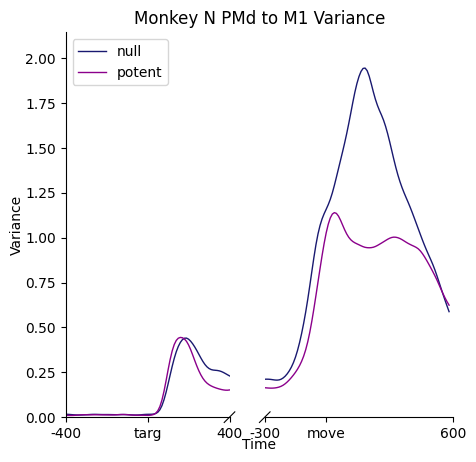

In [5]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 5 23  0 25 17 15 21  4 13 19 11 20  1 22 18  7 16 12 26 10  6  9]
>>> best_lam returning: 20.30917620904739
[14 24 25 17 23  9  6 11 19 20 22 21  8 15  0  4  2  7 13 18 16]
>>> best_lam returning: 11.937766417144381
[18 23 15  9 14 13  1 17  0  8  5  3 10 21 11  6  7  2 19 12]
>>> best_lam returning: 34.55107294592218
[13 16 19 11 10  9  3  1 18  7 20  8 15 14  6  5 12]
>>> best_lam returning: 20.30917620904739
frac null:  0.5900277536832781
frac potent:  0.40997224631672213


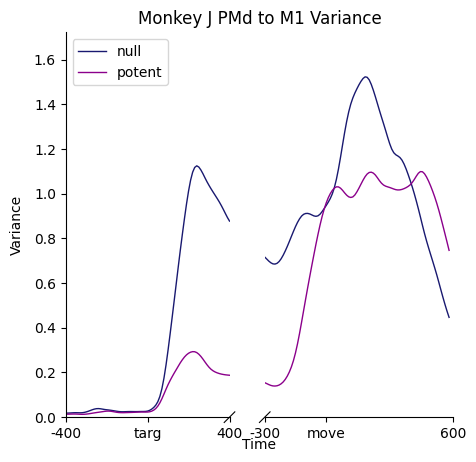

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[11 14 12 19 18 25  7 16  8 24  9  2 13  3  0 26 20 21 10  1  6 22]
>>> best_lam returning: 34.55107294592218
[23 14 22 24  0  8 13 16 15 20  1 17  2  4  6 18 25  9  5 19 11]
>>> best_lam returning: 20.30917620904739
[ 9  7 16  2 17 14 19 21 23 11 12 18 13  1  6  0  8 22 20 15]
>>> best_lam returning: 20.30917620904739
[11 14  4 15 20  9 17  5 18  0  8  2 16  3  6 10  7]
>>> best_lam returning: 20.30917620904739
frac null:  0.5816079505781232
frac potent:  0.418392049421877


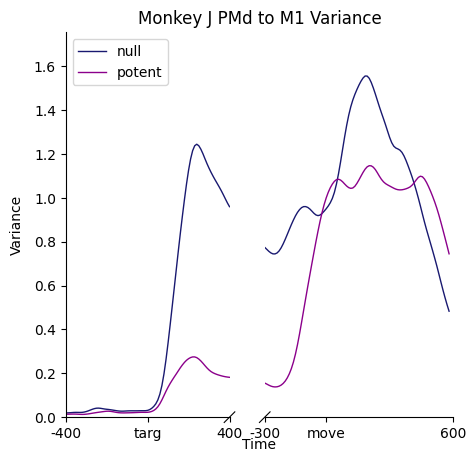

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[15  9 18 11  0 20 10  7 12 23 25  4 17 16 19  5  3  6 13  2 24  1]
>>> best_lam returning: 20.30917620904739
frac null:  0.754078515448521
frac potent:  0.24592148455147858


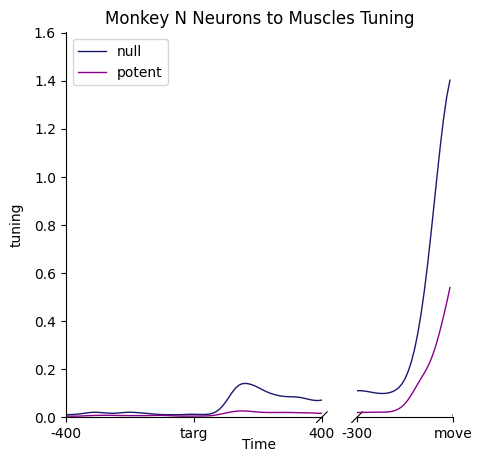

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)